In [1]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

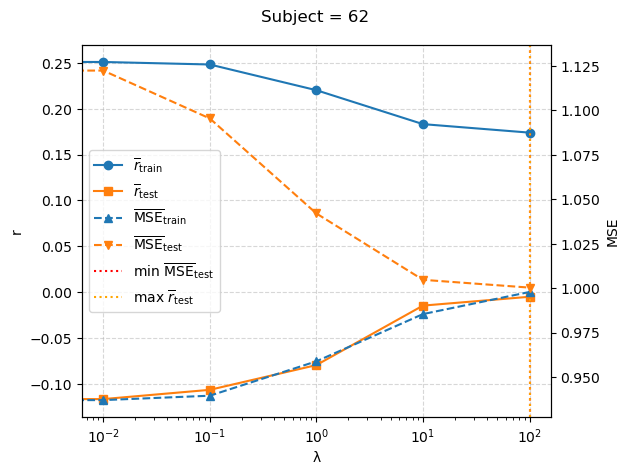

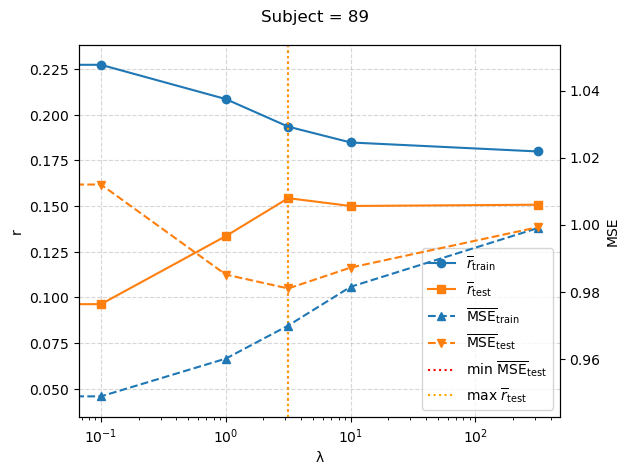

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer"

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SUBJECTS = [62, 89]
for sub in SUBJECTS:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        #print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    # Ensure numeric & sort by lam
    num_cols = ["lam", "mean_train_mse", "mean_test_mse",  "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=num_cols).sort_values("lam")

    # ---- find best lambda by test MSE (min) and test r (max) ----
    idx_best_mse = df["mean_test_mse"].idxmin()
    lam_best_mse = df.loc[idx_best_mse, "lam"]

    idx_best_r = df["mean_test_r"].idxmax()
    lam_best_r = df.loc[idx_best_r, "lam"]

    # One figure with two y-axes
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()  # second y-axis sharing same x

    # Left axis: correlations
    l1, = ax1.plot(df["lam"], df["mean_train_r"], marker="o",label=r"$\overline{r}_{\text{train}}$")
    l2, = ax1.plot(df["lam"], df["mean_test_r"], marker="s", label=r"$\overline{r}_{\text{test}}$")

    ax1.set_xlabel("λ")
    ax1.set_ylabel("r")
    ax1.set_xscale("log")

    # Right axis: MSE
    l3, = ax2.plot(df["lam"], df["mean_train_mse"], marker="^", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{train}}$")
    l4, = ax2.plot(df["lam"], df["mean_test_mse"], marker="v", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{test}}$")
    ax2.set_ylabel("MSE")

    # ---- vertical lines for best λs ----
    v1 = ax1.axvline(lam_best_mse, linestyle=":", linewidth=1.5, color="red", label=r"min $\overline{\text{MSE}}_{\text{test}}$")
    v2 = ax1.axvline(lam_best_r, linestyle=":", linewidth=1.5, color="orange", label=r"max $\overline{r}_{\text{test}}$")

    # Title & grid
    fig.suptitle(f"Subject = {sub}")
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Single combined legend
    lines = [l1, l2, l3, l4, v1, v2]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="best")

    fig.tight_layout()


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# HERE I delete the lambda 31.622776601683796 because not all subjects have it, and other subjects do not have 100 or 316.2277 so I move everything to 316.227766016838

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer"

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

all_dfs = []

for sub in SUBJECTS:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    num_cols = ["lam", "mean_train_mse", "mean_test_mse",  "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # === NEW BLOCK: tweak λ values per subject =========================
    lam_drop = 31.622776601683796
    lam_100  = 100.0
    lam_316  = 316.227766016838

    # 1) Drop all rows with λ = 31.622776601683796
    df = df[~np.isclose(df["lam"], lam_drop)]

    # 2 & 3) Handle 100 vs 316.227766016838
    has_100 = np.isclose(df["lam"], lam_100).any()
    has_316 = np.isclose(df["lam"], lam_316).any()

    if has_100 and has_316:
        # If both present: drop λ = 100 for this subject
        df = df[~np.isclose(df["lam"], lam_100)]
    elif has_100 and not has_316:
        # If only 100 present: move those rows to λ = 316.227...
        df.loc[np.isclose(df["lam"], lam_100), "lam"] = lam_316
    # if only 316 present or neither present, do nothing
    # ===================================================================

    df = df.dropna(subset=num_cols).sort_values("lam")
    df["subject"] = sub
    all_dfs.append(df)

# ---- Combine all subjects ----
df_all = pd.concat(all_dfs, ignore_index=True)

# ---- Aggregate across subjects per λ ----
agg = (
    df_all
    .groupby("lam")
    .agg(
        mean_train_mse=("mean_train_mse", "mean"),
        mean_test_mse=("mean_test_mse", "mean"),
        mean_train_r=("mean_train_r", "mean"),
        mean_test_r=("mean_test_r", "mean"),
        # stds (optional)
        std_train_mse=("mean_train_mse", "std"),
        std_test_mse=("mean_test_mse", "std"),
        std_train_r=("mean_train_r", "std"),
        std_test_r=("mean_test_r", "std"),
        n=("subject", "nunique")
    )
    .reset_index()
)

# ---- find λ with min test MSE and max test r (on the averaged curves) ----
idx_best_mse = agg["mean_test_mse"].idxmin()
lam_best_mse = agg.loc[idx_best_mse, "lam"]

idx_best_r = agg["mean_test_r"].idxmax()
lam_best_r = agg.loc[idx_best_r, "lam"]

print("Best λ (min mean_test_mse):", lam_best_mse)
print("Best λ (max mean_test_r):", lam_best_r)

# ---- Plot ----
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Left y-axis: correlations
l1, = ax1.plot(
    agg["lam"], agg["mean_train_r"], marker="o",
    label=r"$\overline{r}_{\text{train}}$"
)
l2, = ax1.plot(
    agg["lam"], agg["mean_test_r"], marker="s",
    label=r"$\overline{r}_{\text{test}}$"
)
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("r")
ax1.set_xscale("log")

# Right y-axis: MSE
l3, = ax2.plot(
    agg["lam"], agg["mean_train_mse"], marker="^", linestyle="--",
    label=r"$\overline{\text{MSE}}_{\text{train}}$"
)
l4, = ax2.plot(
    agg["lam"], agg["mean_test_mse"], marker="v", linestyle="--",
    label=r"$\overline{\text{MSE}}_{\text{test}}$"
)
ax2.set_ylabel("MSE")

# ---- vertical lines for best λs ----
v1 = ax1.axvline(
    lam_best_mse, linestyle=":", linewidth=1.5, color="red",
    label=r"min $\overline{\text{MSE}}_{\text{test}}$"
)
v2 = ax1.axvline(
    lam_best_r, linestyle=":", linewidth=1.5, color="orange",
    label=r"max $\overline{r}_{\text{test}}$"
)

# Legend combining all lines
lines = [l1, l2, l3, l4, v1, v2]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="best")

fig.suptitle("Ridge regression performance (averaged across subjects)")
fig.tight_layout()
plt.show()


[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k35.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k46.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k68.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k69.csv
Best λ (min mean_test_mse): 3.1622776601683795
Best λ (max mean_test_r): 3.1622776601683795


[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k35.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k46.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k68.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\order_ridge_SLOW_k69.csv


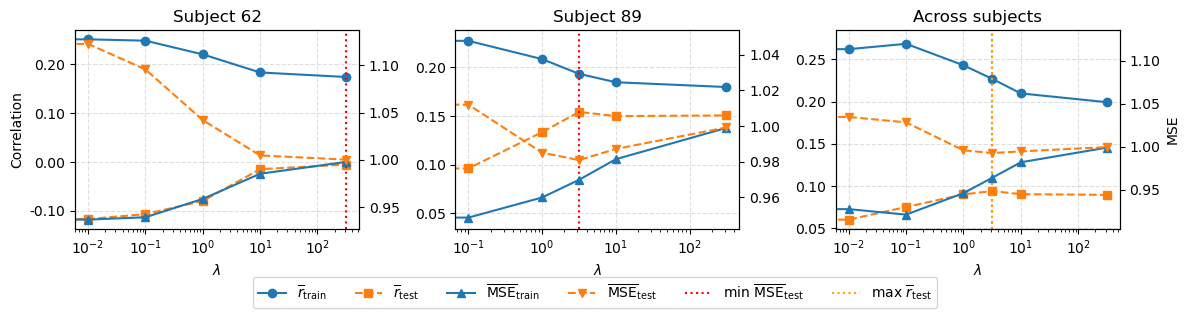

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer"

# all subjects you want to include in the average
SUBJECTS_ALL = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

# the individual subjects you want panels for
SUBJECTS_TO_SHOW = [62, 89]

all_dfs = []
per_subject = {}

for sub in SUBJECTS_ALL:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    num_cols = ["lam", "mean_train_mse", "mean_test_mse",
                "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # === λ harmonisation block (your existing logic) =================
    lam_drop = 31.622776601683796
    lam_100  = 100.0
    lam_316  = 316.227766016838

    # drop λ = 31.62...
    df = df[~np.isclose(df["lam"], lam_drop)]

    has_100 = np.isclose(df["lam"], lam_100).any()
    has_316 = np.isclose(df["lam"], lam_316).any()

    if has_100 and has_316:
        df = df[~np.isclose(df["lam"], lam_100)]
    elif has_100 and not has_316:
        df.loc[np.isclose(df["lam"], lam_100), "lam"] = lam_316
    # =================================================================

    df = df.dropna(subset=num_cols).sort_values("lam")
    df["subject"] = sub
    all_dfs.append(df)

    if sub in SUBJECTS_TO_SHOW:
        per_subject[sub] = df.copy()

# ---------- Combine all subjects for the group-average panel ----------
df_all = pd.concat(all_dfs, ignore_index=True)

agg = (
    df_all
    .groupby("lam")
    .agg(
        mean_train_mse=("mean_train_mse", "mean"),
        mean_test_mse=("mean_test_mse", "mean"),
        mean_train_r=("mean_train_r", "mean"),
        mean_test_r=("mean_test_r", "mean"),
        std_train_mse=("mean_train_mse", "std"),
        std_test_mse=("mean_test_mse", "std"),
        std_train_r=("mean_train_r", "std"),
        std_test_r=("mean_test_r", "std"),
        n=("subject", "nunique")
    )
    .reset_index()
)

# best λ on the averaged curves
idx_best_mse_group = agg["mean_test_mse"].idxmin()
lam_best_mse_group = agg.loc[idx_best_mse_group, "lam"]

idx_best_r_group = agg["mean_test_r"].idxmax()
lam_best_r_group = agg.loc[idx_best_r_group, "lam"]

# best λ (min test MSE) for each individual subject
best_lam_subj = {
    sub: df.loc[df["mean_test_mse"].idxmin(), "lam"]
    for sub, df in per_subject.items()
}

# ---------- Global y-ranges (across all subjects) ----------
all_r_vals = np.r_[
    df_all["mean_train_r"].values,
    df_all["mean_test_r"].values
]
all_mse_vals = np.r_[
    df_all["mean_train_mse"].values,
    df_all["mean_test_mse"].values
]


# ---------- Make the 3-panel figure ----------
n_panels = len(SUBJECTS_TO_SHOW) + 1  # +1 for the group-average
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 3.2), sharex=False)

# if only one panel, axes is not an array; make it iterable
if n_panels == 1:
    axes = [axes]

all_lines = []

# ---- Panels for individual subjects ----
for j, sub in enumerate(SUBJECTS_TO_SHOW):
    ax = axes[j]
    df = per_subject[sub]
    lam = df["lam"].values

    # left y-axis: correlations
    ax.set_xscale("log")
    line_r_tr, = ax.plot(lam, df["mean_train_r"], marker="o", linestyle="-",
                         label=r"$\overline{r}_{\mathrm{train}}$")
    line_r_te, = ax.plot(lam, df["mean_test_r"], marker="s", linestyle="--",
                         label=r"$\overline{r}_{\mathrm{test}}$")
    ax.set_xlabel(r"$\lambda$")
    if j == 0:
        ax.set_ylabel("Correlation")
    ax.set_title(f"Subject {sub}")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # right y-axis: MSE
    ax2 = ax.twinx()
    line_mse_tr, = ax2.plot(lam, df["mean_train_mse"], marker="^", linestyle="-",
                            label=r"$\overline{\mathrm{MSE}}_{\mathrm{train}}$")
    line_mse_te, = ax2.plot(lam, df["mean_test_mse"], marker="v", linestyle="--",
                            label=r"$\overline{\mathrm{MSE}}_{\mathrm{test}}$")
    if j == n_panels - 1:
        ax2.set_ylabel("MSE")

    # vertical line: min test MSE
    v_sub = ax.axvline(
        best_lam_subj[sub],
        linestyle=":",
        linewidth=1.5,
        color="red",
        label=r"min $\overline{\mathrm{MSE}}_{\mathrm{test}}$"
    )

    all_lines.extend([line_r_tr, line_r_te, line_mse_tr, line_mse_te, v_sub])

# ---- Panel for group-average curves ----
ax = axes[-1]
lam = agg["lam"].values

ax.set_xscale("log")
line_r_tr, = ax.plot(lam, agg["mean_train_r"], marker="o", linestyle="-",
                     label=r"$\overline{r}_{\mathrm{train}}$")
line_r_te, = ax.plot(lam, agg["mean_test_r"], marker="s", linestyle="--",
                     label=r"$\overline{r}_{\mathrm{test}}$")
ax.set_xlabel(r"$\lambda$")
ax.set_title("Across subjects")
ax.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax2 = ax.twinx()
line_mse_tr, = ax2.plot(lam, agg["mean_train_mse"], marker="^", linestyle="-",
                        label=r"$\overline{\mathrm{MSE}}_{\mathrm{train}}$")
line_mse_te, = ax2.plot(lam, agg["mean_test_mse"], marker="v", linestyle="--",
                        label=r"$\overline{\mathrm{MSE}}_{\mathrm{test}}$")
ax2.set_ylabel("MSE")

v1 = ax.axvline(
    lam_best_mse_group, linestyle=":", linewidth=1.5, color="red",
    label=r"min $\overline{\mathrm{MSE}}_{\mathrm{test}}$"
)
v2 = ax.axvline(
    lam_best_r_group, linestyle=":", linewidth=1.5, color="orange",
    label=r"max $\overline{r}_{\mathrm{test}}$"
)

all_lines.extend([line_r_tr, line_r_te, line_mse_tr, line_mse_te, v1, v2])

# ---------- Global legend (unique labels, like in your sim figure) ----------
seen = set()
uniq_lines = []
uniq_labels = []
for line in all_lines:
    lab = line.get_label()
    if lab not in seen:
        seen.add(lab)
        uniq_lines.append(line)
        uniq_labels.append(lab)

fig.legend(
    uniq_lines,
    uniq_labels,
    loc="lower center",
    ncol=len(uniq_lines),      # one row
    bbox_to_anchor=(0.5, 0)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave room for legend at bottom
# plt.savefig("ridge_real_subjects_and_group.png", dpi=300)
plt.show()


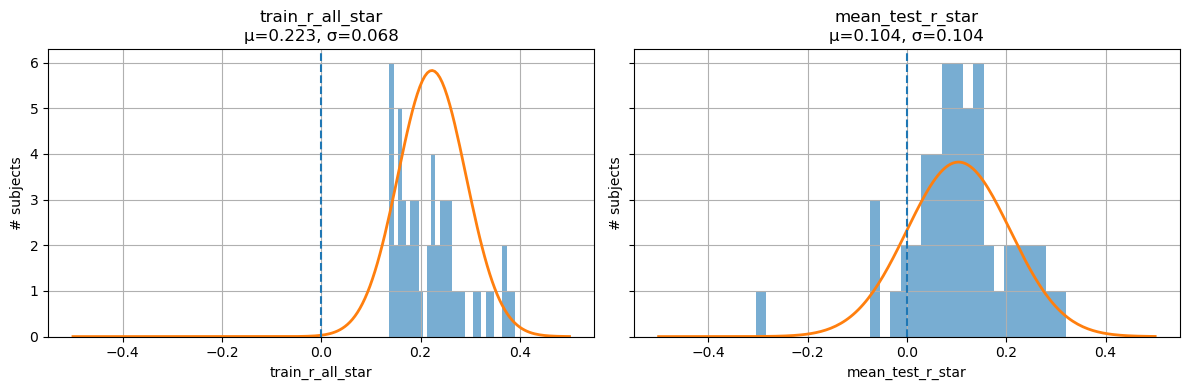

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_UPDATE.csv"
df = pd.read_csv(path)

cols = ["train_r_all_star", "mean_test_r_star"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, cols):
    vals = df[col].dropna()
    
    # Histogram as density
    ax.hist(vals, bins=30, alpha=0.6)
    
    # Fit normal distribution
    mu, sigma = norm.fit(vals)
    
    # X range for the curve
    x_min, x_max = vals.min(), vals.max()
    x_min, x_max = -0.5, 0.5
    x = np.linspace(x_min, x_max, 200)
    pdf = norm.pdf(x, mu, sigma)
    
    # Plot fitted normal curve
    ax.plot(x, pdf, linewidth=2)
    
    # Reference at 0
    ax.axvline(0, linestyle="--")
    
    ax.set_title(f"{col}\nμ={mu:.3f}, σ={sigma:.3f}")
    ax.set_xlabel(col)
    ax.grid(True)
    ax.set_ylabel("# subjects")

plt.tight_layout()
plt.show()


In [3]:
import numpy as np
from scipy import stats

for col in ["train_r_all_star", "mean_test_r_star"]:
    vals = df[col].dropna()
    mean = vals.mean()
    std = vals.std(ddof=1)
    n = len(vals)
    t_stat, p_val = stats.ttest_1samp(vals, 0, alternative='greater')

    print(f"\nColumn: {col}")
    print(f"  n = {n}")
    print(f"  mean = {mean:.4f}, std = {std:.4f}")
    print(f"  t-stat = {t_stat:.3f}, p-value = {p_val:.5f}")



Column: train_r_all_star
  n = 53
  mean = 0.2229, std = 0.0691
  t-stat = 23.479, p-value = 0.00000

Column: mean_test_r_star
  n = 53
  mean = 0.1040, std = 0.1054
  t-stat = 7.187, p-value = 0.00000


Train λ=0 n = 53, mean = 0.2642
Train λ*  n = 53, mean = 0.2229
# test files found:      53
Test λ=0     n = 53, mean = 0.0717
Test best λ≠0 n = 53, mean = 0.1138


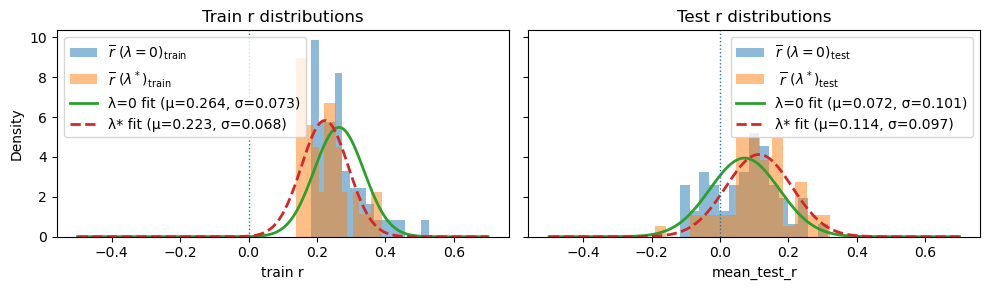

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------- 1) TRAIN r from dfk_ridge_TMP.csv ----------
base_dir = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer"

df_train = pd.read_csv(os.path.join(base_dir, "dfk_ridge_UPDATE.csv"))

train_star = df_train["train_r_all_star"].dropna().to_numpy()
train_lam0 = df_train["train_r_all_lam0"].dropna().to_numpy()

print(f"Train λ=0 n = {len(train_lam0)}, mean = {train_lam0.mean():.4f}")
print(f"Train λ*  n = {len(train_star)}, mean = {train_star.mean():.4f}")

# ---------- 2) TEST r from order_ridge_SLOW_kXX.csv ----------
pattern = os.path.join(base_dir, "order_ridge_SLOW_k*.csv")
files = glob.glob(pattern)

lam0_vals = []       # mean_test_r for λ = 0
best_non0_vals = []  # best mean_test_r for λ ≠ 0

for f in files:
    df = pd.read_csv(f)
    df["lam"] = df["lam"].astype(float)

    # λ = 0
    lam0_row = df.loc[df["lam"] == 0.0]
    if not lam0_row.empty:
        lam0_vals.append(lam0_row["mean_test_r"].iloc[0])

    # best λ ≠ 0
    non0 = df.loc[df["lam"] != 0.0]
    if not non0.empty:
        best_row = non0.loc[non0["mean_test_r"].idxmax()]
        best_non0_vals.append(best_row["mean_test_r"])

lam0_vals = np.array(lam0_vals)
best_non0_vals = np.array(best_non0_vals)

print(f"# test files found:      {len(files)}")
print(f"Test λ=0     n = {len(lam0_vals)}, mean = {lam0_vals.mean():.4f}")
print(f"Test best λ≠0 n = {len(best_non0_vals)}, mean = {best_non0_vals.mean():.4f}")

# ---------- 3) Plot: train (left) and test (right) with Gaussian fits ----------
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
bins = 15

# ---- Left: TRAIN r distributions ----
ax = axes[0]

ax.hist(train_lam0, bins=bins, density=True, alpha=0.5, label=r"$\overline{r}\ (λ=0)_{\mathrm{train}}$")
ax.hist(train_star, bins=bins, density=True, alpha=0.5, label=r"$\overline{r}\ (λ^*)_{\mathrm{train}}$")

x_min = min(train_star.min(), train_lam0.min())
x_max = max(train_star.max(), train_lam0.max())
x_min, x_max = -0.5, 0.7
x = np.linspace(x_min, x_max, 300)

mu_star, sigma_star = norm.fit(train_star)
mu_l0, sigma_l0 = norm.fit(train_lam0)

pdf_star = norm.pdf(x, mu_star, sigma_star)
pdf_l0 = norm.pdf(x, mu_l0, sigma_l0)

ax.plot(x, pdf_l0, linewidth=2, label=f"λ=0 fit (μ={mu_l0:.3f}, σ={sigma_l0:.3f})")
ax.plot(x, pdf_star, linewidth=2, linestyle="--", label=f"λ* fit (μ={mu_star:.3f}, σ={sigma_star:.3f})")


ax.axvline(0, linestyle=":", linewidth=1)
ax.set_title("Train r distributions")
ax.set_xlabel("train r")
ax.set_ylabel("Density")
ax.legend()

# ---- Right: TEST r distributions ----
ax = axes[1]

ax.hist(lam0_vals, bins=bins, density=True, alpha=0.5, label=r"$\overline{r}\ (λ=0)_{\mathrm{test}}$")
ax.hist(best_non0_vals, bins=bins, density=True, alpha=0.5, label=r" $\overline{r}\ (λ^*)_{\mathrm{test}}$")

x_min = min(lam0_vals.min(), best_non0_vals.min())
x_max = max(lam0_vals.max(), best_non0_vals.max())
x_min, x_max = -0.5, 0.7
x = np.linspace(x_min, x_max, 300)

mu_t0, sigma_t0 = norm.fit(lam0_vals)
mu_t1, sigma_t1 = norm.fit(best_non0_vals)

pdf_t0 = norm.pdf(x, mu_t0, sigma_t0)
pdf_t1 = norm.pdf(x, mu_t1, sigma_t1)

ax.plot(x, pdf_t0, linewidth=2,  label=f"λ=0 fit (μ={mu_t0:.3f}, σ={sigma_t0:.3f})")
ax.plot(x, pdf_t1, linewidth=2, linestyle="--", label=f"λ* fit (μ={mu_t1:.3f}, σ={sigma_t1:.3f})")

ax.axvline(0, linestyle=":", linewidth=1)
ax.set_title("Test r distributions")
ax.set_xlabel("mean_test_r")
ax.legend()

plt.tight_layout()
plt.show()


In [9]:
from scipy import stats
import numpy as np

# ---------- Helper: one-sample t-test + 95% CI ----------
def one_sample_t_test_ci(data, mu0=0.0, alpha=0.05, alternative="greater"):
    """
    data: 1D array
    mu0: null-hypothesis mean
    alternative: "greater" (mean > mu0), "less", or "two-sided"
    """
    data = np.asarray(data)
    n = len(data)
    mean = data.mean()
    sd = data.std(ddof=1)
    se = sd / np.sqrt(n)
    df = n - 1

    # t-statistic
    t_stat = (mean - mu0) / se

    # two-sided p-value from SciPy
    p_two = stats.t.sf(np.abs(t_stat), df) * 2.0

    # adjust for one-sided if needed
    if alternative == "greater":
        if mean > mu0:
            p_val = p_two / 2.0
        else:
            p_val = 1.0 - p_two / 2.0
    elif alternative == "less":
        if mean < mu0:
            p_val = p_two / 2.0
        else:
            p_val = 1.0 - p_two / 2.0
    else:  # "two-sided"
        p_val = p_two

    # 95% CI for the mean (always two-sided CI)
    t_crit = stats.t.ppf(1.0 - alpha/2.0, df)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se

    return {
        "n": n,
        "mean": mean,
        "sd": sd,
        "se": se,
        "t": t_stat,
        "df": df,
        "p": p_val,
        "ci": (ci_low, ci_high),
    }

# ---------- 1) Is mean test r > 0 for λ = 0? ----------
res_lam0 = one_sample_t_test_ci(lam0_vals, mu0=0.0, alternative="greater")
print("\nTest r for λ = 0:")
print(f"  n = {res_lam0['n']}")
print(f"  mean = {res_lam0['mean']:.4f}")
print(f"  SD = {res_lam0['sd']:.4f}")
print(f"  t({res_lam0['df']}) = {res_lam0['t']:.3f}, one-sided p = {res_lam0['p']:.4g}")
print(f"  95% CI for mean r: [{res_lam0['ci'][0]:.4f}, {res_lam0['ci'][1]:.4f}]")

# ---------- 2) Is mean test r > 0 for best λ ≠ 0? ----------
res_best = one_sample_t_test_ci(best_non0_vals, mu0=0.0, alternative="greater")
print("\nTest r for best λ ≠ 0:")
print(f"  n = {res_best['n']}")
print(f"  mean = {res_best['mean']:.4f}")
print(f"  SD = {res_best['sd']:.4f}")
print(f"  t({res_best['df']}) = {res_best['t']:.3f}, one-sided p = {res_best['p']:.4g}")
print(f"  95% CI for mean r: [{res_best['ci'][0]:.4f}, {res_best['ci'][1]:.4f}]")

# ---------- 3) Per-subject difference: best λ − λ = 0 ----------
# This assumes lam0_vals[i] and best_non0_vals[i] are aligned by subject.
# (They should be, because you append both inside the same file loop.)
diff = best_non0_vals - lam0_vals

res_diff = one_sample_t_test_ci(diff, mu0=0.0, alternative="greater")
print("\nDifference in test r (best λ − λ = 0):")
print(f"  n = {res_diff['n']}")
print(f"  mean diff = {res_diff['mean']:.4f}")
print(f"  SD diff = {res_diff['sd']:.4f}")
print(f"  t({res_diff['df']}) = {res_diff['t']:.3f}, one-sided p = {res_diff['p']:.4g}")
print(f"  95% CI for mean diff: [{res_diff['ci'][0]:.4f}, {res_diff['ci'][1]:.4f}]")



Test r for λ = 0:
  n = 53
  mean = 0.0717
  SD = 0.1021
  t(52) = 5.113, one-sided p = 2.313e-06
  95% CI for mean r: [0.0436, 0.0999]

Test r for best λ ≠ 0:
  n = 53
  mean = 0.1138
  SD = 0.0976
  t(52) = 8.488, one-sided p = 1.087e-11
  95% CI for mean r: [0.0869, 0.1408]

Difference in test r (best λ − λ = 0):
  n = 53
  mean diff = 0.0421
  SD diff = 0.0532
  t(52) = 5.762, one-sided p = 2.286e-07
  95% CI for mean diff: [0.0275, 0.0568]


## TEST CORRELATION asymptote
$\rho_{\lambda \rightarrow \infty} = corr(X^TXy, y)$

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

BASE = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course")
RIDGE_BASE = BASE / "THESIS" / "ridge_reg" / "1_layer"

# ---------------------------------------------------------
# Load per-subject best lags
# ---------------------------------------------------------
df_lags = pd.read_csv(RIDGE_BASE / "dfk_ridge_UPDATE.csv")

# Guess the subject column name (adjust if you know it)
for cand in ["subj", "subject", "sub", "id"]:
    if cand in df_lags.columns:
        SUBJ_COL = cand
        break
else:
    raise ValueError(f"No subject column found in {df_lags.columns}")

if "best_lag_ms_star" not in df_lags.columns:
    raise ValueError("Column 'best_lag_ms_star' not found in dfk_ridge_UPDATE.csv")

best_shift_per_subj = {}

for _, row in df_lags.iterrows():
    subj = int(row[SUBJ_COL])

    lag_ms = float(row["best_lag_ms_star"])   # in milliseconds
    # Your code uses 10 ms units: lag_ms = shift * 10
    shift_units = int(round(lag_ms / 10.0))   # convert ms → samples (10 ms per sample)

    best_shift_per_subj[subj] = shift_units

print(best_shift_per_subj)


{33: 150, 34: -137, 36: -18, 38: -55, 39: -150, 40: -150, 41: 95, 42: 150, 43: -41, 44: -9, 45: 150, 47: -150, 48: -150, 49: -9, 50: -49, 51: -146, 52: -114, 54: 78, 55: 150, 56: -150, 57: -150, 58: -150, 59: -150, 60: -116, 62: 150, 63: -111, 64: 89, 65: -136, 67: -98, 70: -150, 71: 150, 72: 150, 73: -26, 74: 48, 75: -84, 76: -125, 77: 51, 79: -27, 80: 110, 81: -150, 82: -39, 83: -68, 85: 91, 86: -129, 87: 102, 88: 40, 89: -150, 91: -150, 92: -90, 93: -145, 95: -16, 97: 150, 98: -25}


In [ ]:
## WE CHECK THE ASYMPTOTE BUT FIXE THE LAG

import numpy as np
import pandas as pd
from pathlib import Path

from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    make_triplets_by_load,
    loto_folds_from_triplets,
    candidate_lags_units,
    cross_validate_lambda,
    concat_trials,
    ridge_wx,
    pearsonr
)

# ---------------------------------------------------------------------
# Paths & constants (adapt only if needed)
# ---------------------------------------------------------------------
BASE = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course")
EEG_ROOT   = BASE / "eeg_slow"
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")

TRIM_MS = 100

# Use the same SUBJECTS definition you already had, or a subset:
SUBJECTS = np.setdiff1d(np.arange(32, 99),
                        [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

# If you already built best_shift_per_subj, keep using that.
# Otherwise, reconstruct it from dfk_ridge_UPDATE.csv:

RIDGE_BASE = BASE / "THESIS" / "ridge_reg" / "1_layer"
lags_df = pd.read_csv(RIDGE_BASE / "dfk_ridge_UPDATE.csv")

# adjust the subject column name if needed:
subj_col = "subj" if "subj" in lags_df.columns else lags_df.columns[0]

best_shift_per_subj = {
    int(row[subj_col]): int(round(row["best_lag_ms_star"] / 10.0))
    for _, row in lags_df.iterrows()
}

# ---------------------------------------------------------------------
# Helper: make simple LOTO folds of trials_memory
# ---------------------------------------------------------------------
def make_loto_folds(trials):
    """Leave-one-trial-out folds on a list of trial dicts."""
    folds = []
    for i in range(len(trials)):
        test  = [trials[i]]
        train = [trials[j] for j in range(len(trials)) if j != i]
        folds.append({"train": train, "test": test})
    return folds

# Helper: compute corr safely
def corr(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    if np.allclose(a, a.mean()) or np.allclose(b, b.mean()):
        return np.nan
    r, _ = pearsonr(a, b)
    return r

# ---------------------------------------------------------------------
# Analysis for a few subjects
# ---------------------------------------------------------------------
#SUBJS_TO_ANALYSE = [34, 39, 51]  # change as you like
SUBJS_TO_ANALYSE = SUBJECTS

# a grid of lambdas including very large values
LAMBDAS = [0.0, 0.01, 0.1, 1.0, 3.162, 10.0, 31.62, 100.0, 316.2, 1e3, 1e4, 1e5]

summary_rows = []

for subj in SUBJS_TO_ANALYSE:
    if subj == 68:
        continue

    print(f"\n========== Subject {subj:02d} ==========")
    shift = best_shift_per_subj.get(subj, 0)
    print(f"Using shift = {shift} samples")

    # 1) Load memory trials for this subject
    all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)
    trials_memory, _ = split_trials_by_condition(all_trials)

    print(f"Number of memory trials: {len(trials_memory)}")
    if len(trials_memory) < 6:
        print("Not enough trials for meaningful CV; skipping.")
        continue

    # 2) Build LOTO folds
    rng = np.random.default_rng(42 + subj)
    mem_triplets = make_triplets_by_load(trials_memory, condition_name="memory", rng=rng)
    folds = loto_folds_from_triplets(mem_triplets)
    print(f"  triplets: {len(mem_triplets)}, folds: {len(folds)}")

    # 3) Compute the theoretical CV asymptote:
    #    for each fold, corr(X_te X_tr^T y_tr, y_te)
    rho_inf_folds = []

    for fold_idx, fold in enumerate(folds):
        train_trials = fold["train"]
        test_trials  = fold["test"]

        X_tr, y_tr = concat_trials(train_trials, shift=shift, trim=TRIM_MS)
        X_te, y_te = concat_trials(test_trials,  shift=shift, trim=TRIM_MS)

        if len(y_tr) == 0 or len(y_te) == 0:
            rho_inf_folds.append(np.nan)
            continue

        # centre (optional but cleaner)
        X_tr_c = X_tr - X_tr.mean(axis=0, keepdims=True)
        y_tr_c = y_tr - y_tr.mean()
        X_te_c = X_te - X_te.mean(axis=0, keepdims=True)
        y_te_c = y_te - y_te.mean()

        # asymptotic test prediction direction for this fold:
        # y_hat_te_inf ∝ X_te_c X_tr_c^T y_tr_c
        XXT_y_tr = X_te_c @ (X_tr_c.T @ y_tr_c)

        r_inf_fold = corr(XXT_y_tr, y_te_c)
        rho_inf_folds.append(r_inf_fold)

    rho_inf_cv = np.nanmean(rho_inf_folds)
    print(f"Mean CV asymptote rho_inf ≈ {rho_inf_cv:.4f}")

    # 4) Now actually run ridge on these same folds for various λ
    mean_test_r_by_lam = []

    for lam in LAMBDAS:
        test_rs = []
        for fold_idx, fold in enumerate(folds):
            train_trials = fold["train"]
            test_trials  = fold["test"]

            X_tr, y_tr = concat_trials(train_trials, shift=shift, trim=TRIM_MS)
            X_te, y_te = concat_trials(test_trials,  shift=shift, trim=TRIM_MS)

            if len(y_tr) == 0 or len(y_te) == 0:
                continue

            # fit ridge on TRAIN for this fixed shift and λ
            w_ridge = ridge_wx(X_tr, y_tr, lam, normalise=False)
            # evaluate on TEST
            y_hat_te = X_te @ w_ridge
            r_te = corr(y_hat_te, y_te)
            test_rs.append(r_te)

        mean_r = np.nanmean(test_rs) if len(test_rs) > 0 else np.nan
        mean_test_r_by_lam.append((lam, mean_r))

    # 5) Report plateau
    #    Look at the last few λ values
    print("λ vs mean_test_r:")
    for lam, r_val in mean_test_r_by_lam:
        print(f"  λ = {lam:8g}, mean_test_r = {r_val: .4f}")

    # pick "plateau" as mean_test_r at the largest λ
    lam_max, r_at_lam_max = mean_test_r_by_lam[-1]
    print(f"\nSubject {subj:02d}:")
    print(f"  CV-asymptote rho_inf ≈ {rho_inf_cv:.4f}")
    print(f"  mean_test_r at λ = {lam_max:g} ≈ {r_at_lam_max:.4f}")

    summary_rows.append({
        "subj": subj,
        "rho_inf_cv": rho_inf_cv,
        "lam_max": lam_max,
        "mean_test_r_lam_max": r_at_lam_max
    })

summary_df = pd.DataFrame(summary_rows)
print("\n===== Summary over analysed subjects =====")
print(summary_df)



========== Subject 33 ==========
Using shift = 150 samples
Number of memory trials: 106
[memory] trials per load: 5→35, 9→35, 13→36
[memory] Created 35 balanced 5–9–13 triplets.
[memory] 1 leftover trials after balanced triplets.
[memory] Attached 1 leftover trial(s) to existing triplets.
[memory] Final triplet counts: 35 groups, sizes=[4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  triplets: 35, folds: 35
Mean CV asymptote rho_inf ≈ 0.0492
λ vs mean_test_r:
  λ =        0, mean_test_r =  0.0408
  λ =     0.01, mean_test_r =  0.0421
  λ =      0.1, mean_test_r =  0.0491
  λ =        1, mean_test_r =  0.0601
  λ =    3.162, mean_test_r =  0.0576
  λ =       10, mean_test_r =  0.0532
  λ =    31.62, mean_test_r =  0.0506
  λ =      100, mean_test_r =  0.0497
  λ =    316.2, mean_test_r =  0.0494
  λ =     1000, mean_test_r =  0.0493
  λ =    10000, mean_test_r =  0.0492
  λ =   100000, mean_test_r =  0.0492

Subject 33:
  CV-as